In [1]:

import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results_dir = '/home/shashank/sonas_ws/src/scenario_generation/hunav_sim/hunav_evaluator/results'
result_files = glob.glob(os.path.join(results_dir, '*.txt'))

with open(results_file,'r') as f:
    data = f.readlines()
metrics = data[0].strip().split('\t')
values = data[1].strip().split('\t')
assert len(metrics) == len(values)

In [7]:
df_list = []
for file in result_files:
    # Read each .txt file into a DataFrame
    df = pd.read_csv(file, sep='\t')
    # Append the DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)
#print(combined_df.head())
print(combined_df.count(axis=0))

experiment_tag                     37
scenario                           37
algorithm                          37
time_to_reach_goal                 37
path_length                        37
cumulative_heading_changes         37
avg_distance_to_closest_person     37
minimum_distance_to_people         37
maximum_distance_to_people         37
intimate_space_intrusions          37
personal_space_intrusions          37
social_space_intrusions            37
group_intimate_space_intrusions    37
group_personal_space_intrusions    37
group_social_space_intrusions      37
completed                          37
minimum_distance_to_target         37
final_distance_to_target           37
robot_on_person_collision          37
person_on_robot_collision          37
time_not_moving                    37
avg_robot_linear_speed             37
avg_robot_angular_speed            37
avg_acceleration                   37
avg_overacceleration               37
avg_pedestrian_velocity            37
avg_closest_

In [11]:
grouped_df = combined_df.groupby(['scenario', 'algorithm']).mean().reset_index()
grouped_df = grouped_df.dropna(axis=1)
#grouped_df.count(axis=0)
print(grouped_df.describe())


       experiment_tag  time_to_reach_goal  path_length  \
count            12.0           12.000000    12.000000   
mean              1.0           57.151403    21.559898   
std               0.0           24.497961     8.455671   
min               1.0           20.374500     7.748958   
25%               1.0           49.763083    18.556046   
50%               1.0           58.990167    25.798645   
75%               1.0           65.896000    27.564721   
max               1.0          103.361000    28.545152   

       cumulative_heading_changes  avg_distance_to_closest_person  \
count                   12.000000                       12.000000   
mean                     7.931224                        3.522282   
std                      2.890175                        1.626982   
min                      3.996486                        1.014393   
25%                      6.236952                        2.477294   
50%                      7.416515                        3.0840

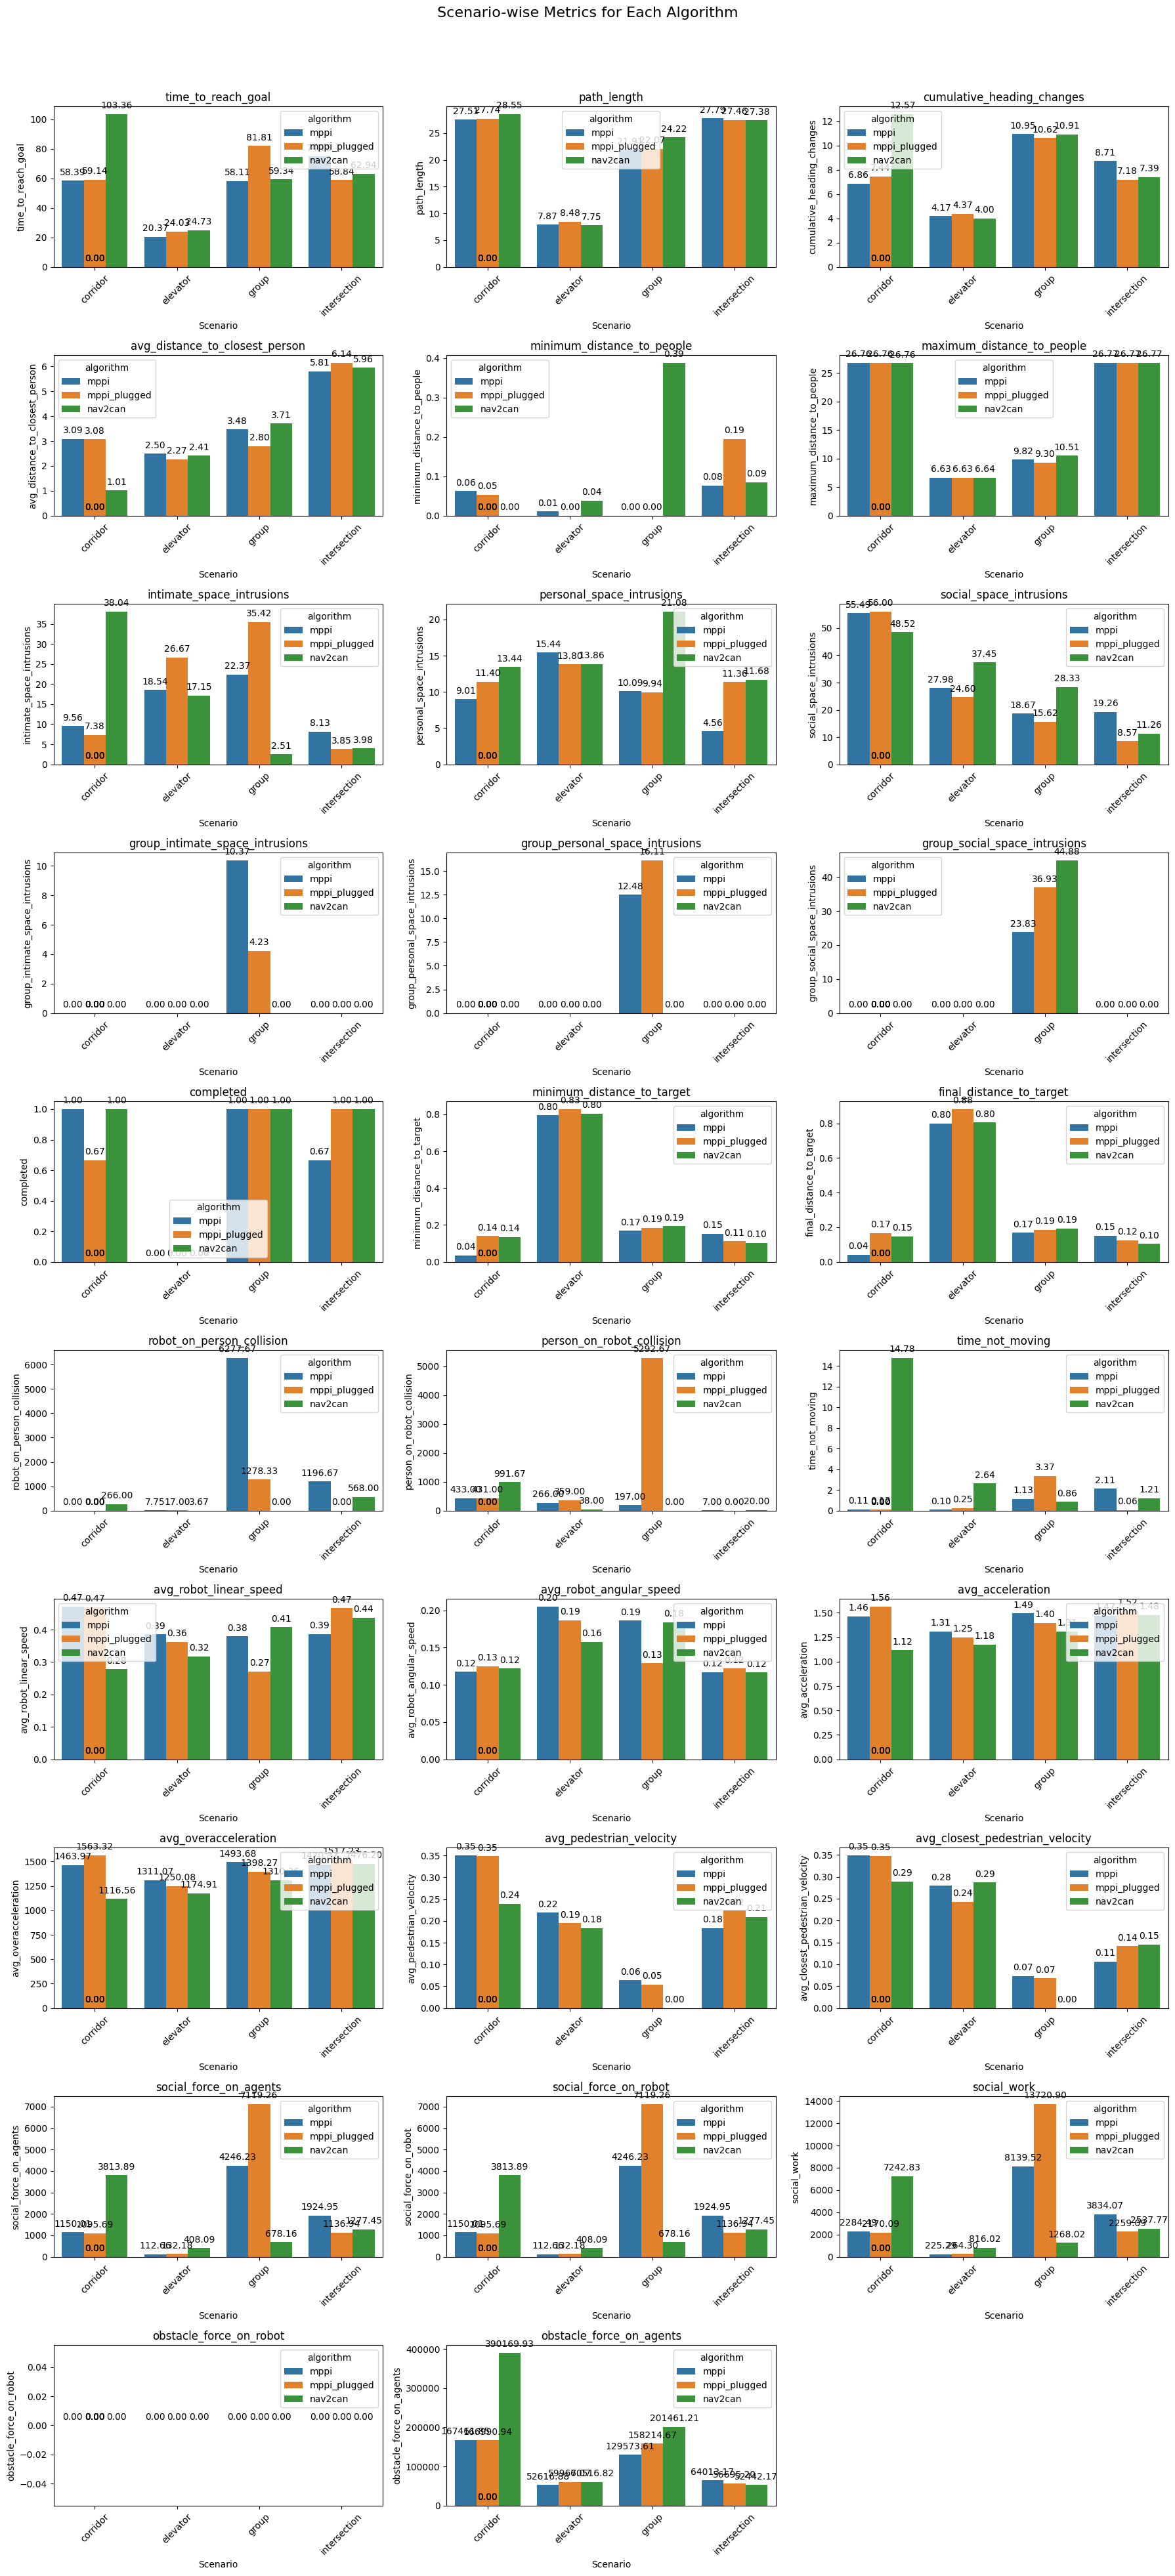

In [12]:
metrics_to_plot = grouped_df.select_dtypes(include=['float64', 'int64']).drop(axis=1,columns=['experiment_tag']).columns.tolist()

# Number of metrics to plot
n_metrics = len(metrics_to_plot)

# Create subplots with an appropriate number of rows and columns
n_cols = 3  # You can adjust this to fit the layout you prefer
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Loop through each metric and create a subplot for each
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.barplot(x='scenario', y=metric, hue='algorithm', data=grouped_df, ax=ax)

    # Set title and labels
    ax.set_title(f'{metric}')
    ax.set_xlabel('Scenario')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

    # Add numbers on top of each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')


# Remove any unused subplots if the grid is not completely filled
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.suptitle('Scenario-wise Metrics for Each Algorithm', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title# Show the plot
plt.show()